# Attention-Based Success/Failure Classifier

**Data**: `profiling_logs_v9` — flip perturbations, banking-only, 6 injection tasks × 6 user-task contexts each.
**Goal**: Within-banking cross-injection generalizability — does an attention signature trained on injection tasks A/B/C predict success for held-out injection D?

**Feature representation**:
For each run, at the first reasoning token (step 0), compute attention mass + entropy from each of 64 heads in each of 24 layers to each of 17 semantic span groups.
Total: 24L × 64H × 17G = **26,112 features** per step (mass block) + same for entropy.

**Analysis stages**:
1. Data audit — per-injection × context breakdown
2. Feature extraction and caching
3. Within-injection cross-context split (it7/ut2 → it7/ut5)
4. Model × feature grid — LogReg, RF, GBM × all feature variants
5. Per-N AUROC (N=1 confound check)
6. Feature importance heatmaps
7. **Within-banking leave-one-injection-out** — primary analysis

In [1]:
import sys, sqlite3, json, dill, pickle, torch, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report,
)
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

try:
    import lightgbm as lgb
    HAS_LGB = True
    print('LightGBM available')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False
    print('LightGBM not available, using sklearn GBM')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── Architecture ───────────────────────────────────────────────────────────────
N_LAYERS          = 24
N_HEADS           = 64
LOCAL_LAYERS      = list(range(0, N_LAYERS, 2))
GLOBAL_LAYERS     = list(range(1, N_LAYERS, 2))
SINK_POSITIONS    = {0}
N_REASONING_STEPS = 10

# ── Fine-grained span groups ───────────────────────────────────────────────────
SPAN_GROUPS = {
    'attack_payload':   {'attack_payload'},
    'attack_prefix':    {'attack_prefix'},
    'attack_suffix':    {'attack_suffix'},
    'user_instruction': {'user_instruction'},
    'tool_env_data':    {'tool_env_data'},
    'dev_instructions': {'developer_instructions'},
    'dev_tools':        {'developer_tools'},
    'system_meta':      {'system_meta'},
    'frame_boundary':   {'frame_boundary'},
    'frame_message':    {'frame_message'},
    'frame_role':       {'frame_role'},
    'frame_channel':    {'frame_channel'},
    'frame_constrain':  {'frame_constrain'},
    'frame_chan_name':  {'frame_channel_name'},
    'frame_cons_type':  {'frame_constrain_type'},
    'frame_metadata':   {'frame_metadata'},
}
GROUP_NAMES = list(SPAN_GROUPS.keys()) + ['sink']
N_GROUPS    = len(GROUP_NAMES)            # 17
N_FEATURES  = N_LAYERS * N_HEADS * N_GROUPS  # per step

LOG_DIR     = Path('profiling_logs_v9')
TENSOR_BASE = Path('.')
CACHE_FILE  = LOG_DIR / 'feature_cache'  # .npz + _meta.pkl appended by loader

GROUP_COLOR = {
    'attack_payload': '#c0392b', 'attack_prefix': '#e74c3c', 'attack_suffix': '#ff7675',
    'user_instruction': '#3498db',
    'tool_env_data': '#f39c12',
    'dev_instructions': '#8e44ad', 'dev_tools': '#9b59b6',
    'system_meta': '#7f8c8d',
    'frame_boundary': '#bdc3c7', 'frame_message': '#b2bec3', 'frame_role': '#adb5bd',
    'frame_channel': '#a8a8a8', 'frame_constrain': '#c0c0c0',
    'frame_chan_name': '#cacaca', 'frame_cons_type': '#d4d4d4', 'frame_metadata': '#dedede',
    'sink': '#1abc9c',
}

print(f'Groups ({N_GROUPS}): {GROUP_NAMES}')
print(f'Feature space per step: {N_LAYERS}L × {N_HEADS}H × {N_GROUPS}G = {N_FEATURES}')

LightGBM not available, using sklearn GBM
Groups (17): ['attack_payload', 'attack_prefix', 'attack_suffix', 'user_instruction', 'tool_env_data', 'dev_instructions', 'dev_tools', 'system_meta', 'frame_boundary', 'frame_message', 'frame_role', 'frame_channel', 'frame_constrain', 'frame_chan_name', 'frame_cons_type', 'frame_metadata', 'sink']
Feature space per step: 24L × 64H × 17G = 26112


/workspace/better_opts_attacks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Load DB ───────────────────────────────────────────────────────────────────
conn = sqlite3.connect(LOG_DIR / 'experiment_logs.db')
cur  = conn.cursor()

cur.execute("SELECT metadata_json FROM logs WHERE event='profiling_run'")
runs_meta = {json.loads(r[0])['run_id']: json.loads(r[0]) for r in cur.fetchall()}

cur.execute("SELECT metadata_json, object_data FROM logs WHERE event='profiling_capture'")
cap_by_run = {}
for meta_json, obj_data in cur.fetchall():
    rid = json.loads(meta_json)['run_id']
    cap_by_run[rid] = dill.loads(obj_data)

conn.close()
print(f'Runs: {len(runs_meta)}   Captures: {len(cap_by_run)}')

# ── Compute true_cumulative_N by token comparison ─────────────────────────────
# Compare each run's payload token_ids against the baseline for that context.
# Overlap-aware: tree re-flipping a position back toward original reduces the count.

def _payload_positions(cap_info):
    payload_tags = {'attack_payload', 'attack_prefix', 'attack_suffix'}
    positions = set()
    for span in cap_info.get('spans', []):
        if span.get('tag') in payload_tags:
            positions.update(range(span['start'], span['end']))
    return positions

baseline_cap_by_ctx = {}
for rid, m in runs_meta.items():
    if m.get('source') == 'baseline' and rid in cap_by_run:
        ctx = (m['suite'], m['injection_task_id'], m['user_task_id'])
        baseline_cap_by_ctx[ctx] = cap_by_run[rid]

print(f'Baseline captures indexed for {len(baseline_cap_by_ctx)} contexts')

n_exact, n_fallback = 0, 0
for rid, m in runs_meta.items():
    own_N = int(m.get('perturbation_N') or 0)
    ctx   = (m.get('suite'), m.get('injection_task_id'), m.get('user_task_id'))
    bl    = baseline_cap_by_ctx.get(ctx)
    run_cap = cap_by_run.get(rid)

    if bl and run_cap:
        bl_ids  = bl.get('token_ids', [])
        run_ids = run_cap.get('token_ids', [])
        if bl_ids and run_ids and len(bl_ids) == len(run_ids):
            payload_pos = _payload_positions(bl)
            m['true_cumulative_N'] = sum(
                1 for p in payload_pos if bl_ids[p] != run_ids[p]
            )
            n_exact += 1
            continue

    # Fallback: additive (only for runs missing captures or mismatched lengths)
    if m.get('source') == 'failure_tree':
        parent = runs_meta.get(m.get('parent_run_id', ''))
        parent_N = int(parent.get('perturbation_N') or 0) if parent else 0
        m['true_cumulative_N'] = own_N + parent_N
    else:
        m['true_cumulative_N'] = own_N
    n_fallback += 1

print(f'true_cumulative_N: {n_exact} exact (token diff), {n_fallback} fallback (additive)')

# ── Flip runs with captures ───────────────────────────────────────────────────
flip_runs = [
    m for m in runs_meta.values()
    if m.get('perturbation_type') == 'flip' and m['run_id'] in cap_by_run
]
print(f'\nFlip runs with caps: {len(flip_runs)}')
print(f'  success: {sum(1 for r in flip_runs if r.get("success"))}')
print(f'  failure: {sum(1 for r in flip_runs if not r.get("success"))}')
print()

from collections import Counter
for src in ('perturbation', 'failure_tree'):
    src_runs = [r for r in flip_runs if r.get('source') == src]
    if not src_runs:
        continue
    n_dist    = Counter(r['true_cumulative_N'] for r in src_runs)
    depth_dist = Counter(r.get('tree_depth', 1) for r in src_runs)
    print(f'{src} ({len(src_runs)} runs):')
    print(f'  true_cumulative_N dist = {dict(sorted(n_dist.items()))}')
    if src == 'failure_tree':
        print(f'  tree_depth dist        = {dict(sorted(depth_dist.items()))}')

Runs: 3784   Captures: 3781
Baseline captures indexed for 27 contexts
true_cumulative_N: 1315 exact (token diff), 2469 fallback (additive)

Flip runs with caps: 3754
  success: 3170
  failure: 584

perturbation (3414 runs):
  true_cumulative_N dist = {1: 762, 2: 899, 3: 191, 4: 807, 5: 221, 6: 365, 7: 46, 8: 67, 9: 56}
failure_tree (340 runs):
  true_cumulative_N dist = {2: 48, 3: 100, 4: 31, 5: 125, 6: 21, 7: 15}
  tree_depth dist        = {1: 340}


In [4]:
# ── Data audit: breakdown by context ─────────────────────────────────────────
audit = defaultdict(lambda: {'success': 0, 'failure': 0})
for m in flip_runs:
    ctx = f"{m.get('suite')}/{m.get('injection_task_id')}/{m.get('user_task_id')}"
    key = 'success' if m.get('success') else 'failure'
    audit[ctx][key] += 1

audit_df = pd.DataFrame([
    {'context': k, 'success': v['success'], 'failure': v['failure'],
     'total': v['success'] + v['failure'],
     'success_rate': v['success'] / (v['success'] + v['failure'])}
    for k, v in sorted(audit.items())
])
print('Per-context breakdown:')
print(audit_df.to_string(index=False, float_format='{:.2f}'.format))

Per-context breakdown:
                              context  success  failure  total  success_rate
 banking/injection_task_1/user_task_0      557       13    570          0.98
banking/injection_task_1/user_task_12      549       23    572          0.96
banking/injection_task_3/user_task_12      692       24    716          0.97
 banking/injection_task_5/user_task_2      544      164    708          0.77
 banking/injection_task_7/user_task_2      562        2    564          1.00
 banking/injection_task_7/user_task_5      266      358    624          0.43


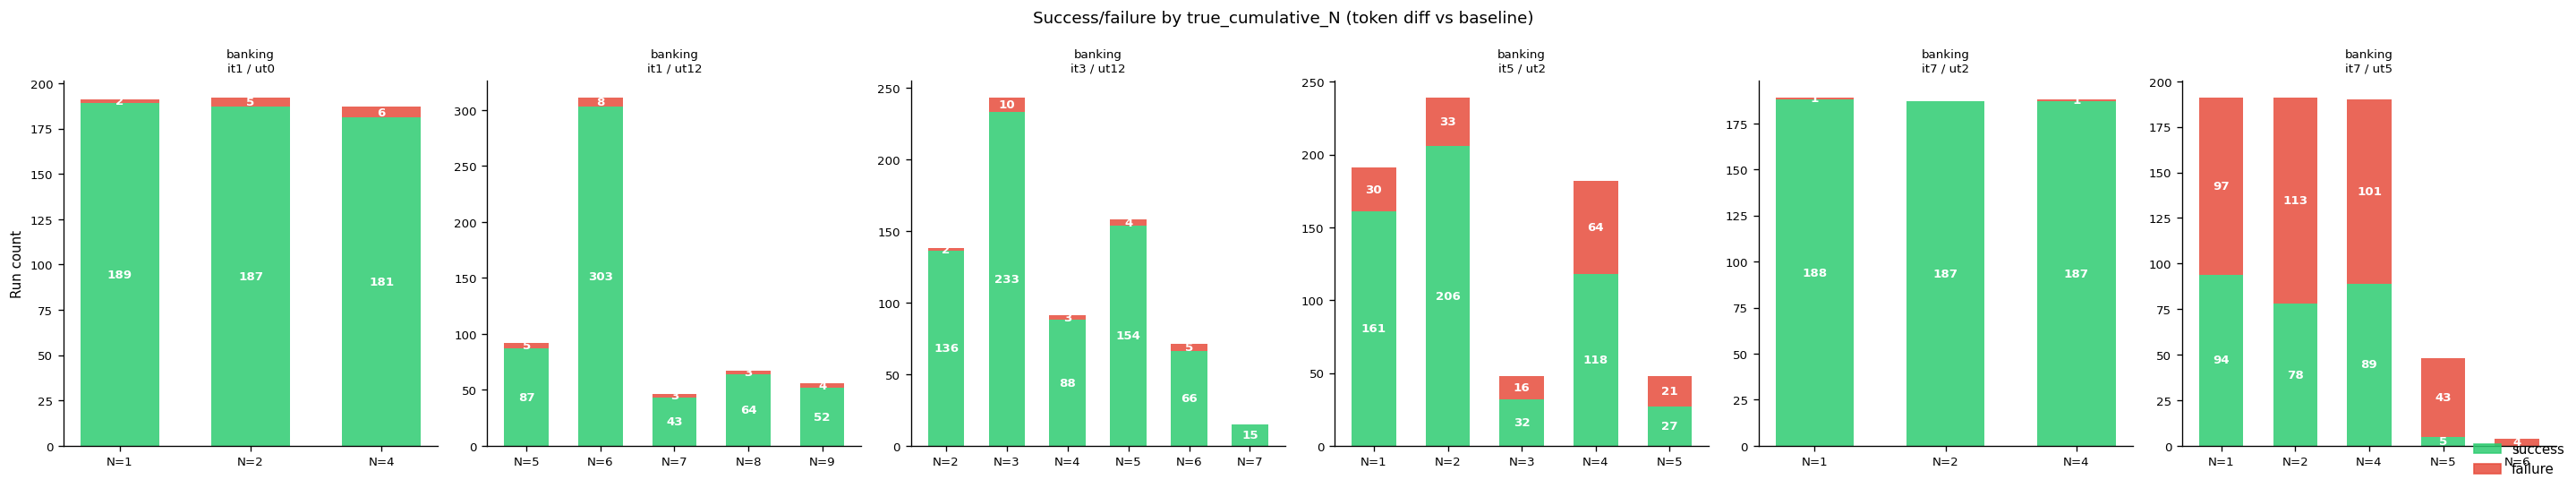

In [5]:
# ── Success/failure stratified by true_cumulative_N ───────────────────────────
# true_cumulative_N = actual token positions differing from baseline in payload span.
# All sources (perturbation + failure_tree) combined.

ctx_N = defaultdict(lambda: defaultdict(lambda: {'success': 0, 'failure': 0}))
for m in flip_runs:
    ctx = (m.get('suite'), m.get('injection_task_id'), m.get('user_task_id'))
    n   = m['true_cumulative_N']
    ctx_N[ctx][n]['success' if m.get('success') else 'failure'] += 1

by_suite = defaultdict(list)
for ctx in sorted(ctx_N):
    by_suite[ctx[0]].append(ctx)
suites = sorted(by_suite)
n_cols = max(len(ctxs) for ctxs in by_suite.values())

fig, axes = plt.subplots(len(suites), n_cols,
                         figsize=(4 * n_cols, 4.5 * len(suites)),
                         sharey=False, squeeze=False)

for ri, suite in enumerate(suites):
    for ci, ctx in enumerate(by_suite[suite]):
        ax       = axes[ri][ci]
        by_N     = ctx_N[ctx]
        N_vals   = sorted(by_N.keys())
        x        = np.arange(len(N_vals))

        for xi, n in enumerate(N_vals):
            s = by_N[n]['success']
            f = by_N[n]['failure']
            ax.bar(xi, s, 0.6, color='#2ecc71', alpha=0.85)
            ax.bar(xi, f, 0.6, bottom=s, color='#e74c3c', alpha=0.85)
            if s > 0:
                ax.text(xi, s / 2, str(s), ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
            if f > 0:
                ax.text(xi, s + f / 2, str(f), ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')

        suite_s, it_s, ut_s = ctx
        ax.set_title(f"{suite_s}\n"
                     f"{it_s.replace('injection_task_', 'it')} / "
                     f"{ut_s.replace('user_task_', 'ut')}", fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'N={n}' for n in N_vals], fontsize=8)
        if ci == 0:
            ax.set_ylabel('Run count')

    for ci in range(len(by_suite[suite]), n_cols):
        axes[ri][ci].set_visible(False)

handles = [
    plt.Rectangle((0,0),1,1, color='#2ecc71', alpha=0.85, label='success'),
    plt.Rectangle((0,0),1,1, color='#e74c3c', alpha=0.85, label='failure'),
]
fig.legend(handles=handles, loc='lower right', fontsize=9, frameon=False)
plt.suptitle('Success/failure by true_cumulative_N (token diff vs baseline)', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
def _span_mask(spans, seq_len, tag_set):
    m = torch.zeros(seq_len, dtype=torch.bool)
    for s in spans:
        if s['tag'] in tag_set:
            m[s['start']:min(s['end'], seq_len)] = True
    for p in SINK_POSITIONS:
        if p < seq_len:
            m[p] = False
    return m


def _extract_features(m, ci, cap, n_steps, normalize):
    """Extract mass + entropy for all reasoning steps from one capture."""
    seq_len = cap['seq_len']
    spans   = ci['spans']
    attn    = cap['attention']

    group_idxs = {}
    for grp, tag_set in SPAN_GROUPS.items():
        mask = _span_mask(spans, seq_len, tag_set)
        group_idxs[grp] = mask.nonzero(as_tuple=False).view(-1)
    sink_idx = torch.tensor([p for p in SINK_POSITIONS if p < seq_len], dtype=torch.long)
    group_idxs['sink'] = sink_idx

    feat_mass = np.zeros((n_steps, N_LAYERS, N_HEADS, N_GROUPS), dtype=np.float32)
    feat_ent  = np.zeros((n_steps, N_LAYERS, N_HEADS, N_GROUPS), dtype=np.float32)

    for li in range(N_LAYERS):
        if li not in attn:
            continue
        a            = attn[li].float()          # [H, actual_steps, klen]
        klen         = a.shape[-1]
        actual_steps = min(n_steps, a.shape[1])

        for step in range(actual_steps):
            a_step = a[:, step, :]               # [H, klen]
            for gi, grp in enumerate(GROUP_NAMES):
                idxs = group_idxs[grp]
                idxs = idxs[idxs < klen]
                if len(idxs) == 0:
                    continue
                span_a = a_step[:, idxs]         # [H, n_tokens]
                feat_mass[step, li, :, gi] = span_a.sum(-1).numpy()
                p   = span_a / (span_a.sum(-1, keepdim=True) + 1e-10)
                ent = -(p * (p + 1e-10).log()).sum(-1)
                feat_ent[step, li, :, gi] = ent.numpy()

    if normalize:
        total = feat_mass.sum(axis=-1, keepdims=True)
        total = np.where(total == 0, 1.0, total)
        feat_mass = feat_mass / total

    return feat_mass.reshape(n_steps, -1), feat_ent.reshape(n_steps, -1)


def _load_and_extract(args, n_steps, normalize):
    """Load one .pt file, extract features, then immediately free the tensor."""
    m, ci, path = args
    if not path.exists():
        return None
    try:
        cap = torch.load(path, map_location='cpu', weights_only=False)
    except Exception:
        return None
    try:
        fm, fe = _extract_features(m, ci, cap, n_steps, normalize)
    except Exception:
        return None
    finally:
        del cap  # free the large attention tensor immediately
    return m, fm, fe


def build_feature_matrix(run_meta_list, n_steps=N_REASONING_STEPS, normalize=True,
                          n_workers=4, cache_file=None, force=False, verbose=True):
    """
    Build [N, n_steps, N_FEATURES] mass and entropy matrices.

    Memory-efficient: each .pt tensor is loaded and feature-extracted in one
    step, then freed before the next batch starts. Only n_workers tensors are
    ever in memory simultaneously. Output arrays are pre-allocated to avoid
    the transient doubling that np.stack() would cause.

    Caches result as .npz + _meta.pkl so subsequent calls are fast.
    """
    cf = Path(str(cache_file) + '.npz') if cache_file else None
    cm = Path(str(cache_file) + '_meta.pkl') if cache_file else None

    # ── Cache check ───────────────────────────────────────────────────────────
    if cf and not force and cf.exists() and cm is not None and cm.exists():
        data         = np.load(cf)
        current_rids = {m['run_id'] for m in run_meta_list if m['run_id'] in cap_by_run}
        if set(data['run_ids'].tolist()) == current_rids:
            if verbose:
                print(f'Cache hit — loading from {cf}')
            with open(cm, 'rb') as f:
                meta_out = pickle.load(f)
            return (data['X_mass'], data['X_entropy'],
                    data['y'].astype(np.int32), meta_out)
        elif verbose:
            print('Cache stale (run_ids changed) — recomputing')

    # ── Build task list ───────────────────────────────────────────────────────
    tasks = [
        (m, cap_by_run[m['run_id']], TENSOR_BASE / cap_by_run[m['run_id']]['cap_path'])
        for m in run_meta_list if m['run_id'] in cap_by_run
    ]
    N_tasks = len(tasks)

    # Pre-allocate output arrays — avoids np.stack() transient doubling.
    # Each row is [n_steps, N_FEATURES] flattened = n_steps * N_LAYERS * N_HEADS * N_GROUPS floats.
    feat_dim  = n_steps * N_FEATURES
    X_mass    = np.empty((N_tasks, n_steps, N_FEATURES), dtype=np.float32)
    X_entropy = np.empty((N_tasks, n_steps, N_FEATURES), dtype=np.float32)
    y_arr     = np.empty(N_tasks, dtype=np.int32)
    meta_out  = [None] * N_tasks
    write_idx = 0
    failed    = 0

    # ── Parallel load+extract (small n_workers to cap concurrent tensor memory) ──
    # With n_workers=4 and ~88 MB per tensor, peak tensor RAM ≈ 350 MB.
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_load_and_extract, t, n_steps, normalize) for t in tasks]
        for fut in tqdm(as_completed(futs), total=N_tasks,
                        desc='Loading + extracting', disable=not verbose):
            r = fut.result()
            if r is None:
                failed += 1
                continue
            m, fm, fe = r
            X_mass[write_idx]    = fm
            X_entropy[write_idx] = fe
            y_arr[write_idx]     = int(bool(m.get('success')))
            meta_out[write_idx]  = m
            write_idx += 1

    # Trim to actual valid rows
    X_mass    = X_mass[:write_idx]
    X_entropy = X_entropy[:write_idx]
    y_arr     = y_arr[:write_idx]
    meta_out  = meta_out[:write_idx]
    run_ids   = np.array([m['run_id'] for m in meta_out])

    if verbose:
        print(f'Processed {write_idx} / {N_tasks} captures  ({failed} failed)')

    # ── Save cache ────────────────────────────────────────────────────────────
    if cf:
        np.savez_compressed(cf, X_mass=X_mass, X_entropy=X_entropy,
                            y=y_arr, run_ids=run_ids)
        with open(cm, 'wb') as f:
            pickle.dump(meta_out, f)
        if verbose:
            print(f'Cache saved → {cf}')

    return X_mass, X_entropy, y_arr, meta_out

In [7]:
X_mass_all, X_entropy_all, y, meta = build_feature_matrix(
    flip_runs, n_steps=N_REASONING_STEPS, normalize=True,
    n_workers=4, cache_file=CACHE_FILE,
)

print(f'X_mass_all:    {X_mass_all.shape}   # [N, steps, L*H*G]')
print(f'X_entropy_all: {X_entropy_all.shape}')
print(f'y: {y.shape}   success={y.sum()}   failure={(1-y).sum()}   ratio={y.sum()/(1-y).sum():.1f}:1')

# Step-0 aliases: [N, N_FEATURES] — used by PCA cell and any cell that needs X_mass
X_mass    = X_mass_all[:, 0, :]
X_entropy = X_entropy_all[:, 0, :]

contexts = np.array([
    f"{m.get('suite')}/{m.get('injection_task_id')}/{m.get('user_task_id')}"
    for m in meta
])
context_labels, context_ids = np.unique(contexts, return_inverse=True)

print('\nContexts:')
for ci_i, cl in enumerate(context_labels):
    mask = context_ids == ci_i
    print(f'  {cl}: n={mask.sum()}  success={y[mask].sum()}  failure={(1-y[mask]).sum()}')

Loading + extracting: 100%|██████████| 3754/3754 [1:23:36<00:00,  1.34s/it]


Processed 3754 / 3754 captures  (0 failed)
Cache saved → profiling_logs_v9/feature_cache.npz
X_mass_all:    (3754, 10, 26112)   # [N, steps, L*H*G]
X_entropy_all: (3754, 10, 26112)
y: (3754,)   success=3170   failure=584   ratio=5.4:1

Contexts:
  banking/injection_task_1/user_task_0: n=570  success=557  failure=13
  banking/injection_task_1/user_task_12: n=572  success=549  failure=23
  banking/injection_task_3/user_task_12: n=716  success=692  failure=24
  banking/injection_task_5/user_task_2: n=708  success=544  failure=164
  banking/injection_task_7/user_task_2: n=564  success=562  failure=2
  banking/injection_task_7/user_task_5: n=624  success=266  failure=358


In [7]:
def make_feature_variants(X_mass_all, X_entropy_all):
    """
    Derive all feature variants from [N, n_steps, N_FEATURES] base tensors.
    Returns dict of name → 2D array [N, d]. No tensor reloading needed.
    """
    N       = len(X_mass_all)
    n_steps = X_mass_all.shape[1]

    # Reshape to [N, steps, L, H, G] for structured slicing
    Xm = X_mass_all.reshape(N, n_steps, N_LAYERS, N_HEADS, N_GROUPS)
    Xe = X_entropy_all.reshape(N, n_steps, N_LAYERS, N_HEADS, N_GROUPS)

    Xm0 = Xm[:, 0]          # step-0 mass    [N, L, H, G]
    Xe0 = Xe[:, 0]          # step-0 entropy

    Xm_mean = Xm.mean(axis=1)   # trajectory mean   [N, L, H, G]
    Xm_max  = Xm.max(axis=1)    # trajectory max
    Xe_mean = Xe.mean(axis=1)

    # Payload/user attention ratio at step 0, per (layer, head) [N, L, H]
    payload_gi = [i for i, g in enumerate(GROUP_NAMES) if 'attack' in g]
    user_gi    = GROUP_NAMES.index('user_instruction')
    p_mass = Xm0[:, :, :, payload_gi].sum(-1)
    u_mass = Xm0[:, :, :, user_gi]
    ratio  = p_mass / (u_mass + 1e-6)

    def flat(*arrs):
        return np.hstack([a.reshape(N, -1) for a in arrs])

    def gl(*arrs):
        """Global layers only."""
        return np.hstack([a[:, GLOBAL_LAYERS].reshape(N, -1) for a in arrs])

    variants = {
        'step0_mass':                    flat(Xm0),
        'step0_mass+entropy':            flat(Xm0, Xe0),
        'step0_global_mass':             gl(Xm0),
        'step0_global_mass+entropy':     gl(Xm0, Xe0),
        'step0_payload_ratio':           ratio.reshape(N, -1),
        'step0_global_ratio':            ratio[:, GLOBAL_LAYERS].reshape(N, -1),
        'traj_mean_mass':                flat(Xm_mean),
        'traj_mean_mass+entropy':        flat(Xm_mean, Xe_mean),
        'traj_global_mean_mass':         gl(Xm_mean),
        'traj_global_mean_mass+entropy': gl(Xm_mean, Xe_mean),
        'traj_mean+max_mass':            flat(Xm_mean, Xm_max),
    }

    print('Feature variants:')
    for name, arr in variants.items():
        print(f'  {name:40s}: {arr.shape[1]:>7} features')
    return variants

feature_variants = make_feature_variants(X_mass_all, X_entropy_all)

Feature variants:
  step0_mass                              :   26112 features
  step0_mass+entropy                      :   52224 features
  step0_global_mass                       :   13056 features
  step0_global_mass+entropy               :   26112 features
  step0_payload_ratio                     :    1536 features
  step0_global_ratio                      :     768 features
  traj_mean_mass                          :   26112 features
  traj_mean_mass+entropy                  :   52224 features
  traj_global_mean_mass                   :   13056 features
  traj_global_mean_mass+entropy           :   26112 features
  traj_mean+max_mass                      :   52224 features


In [ ]:
# ── Cross-context split definition ────────────────────────────────────────────
# Within it7 only: train on ut2 (100% success — clean signal), test on ut5
# (46% success — most balanced context available in v9 for it7).
# ut5 is withheld entirely; the classifier has never seen a ut5 example.

TRAIN_CONTEXTS_CX = {'banking/injection_task_7/user_task_2'}
TEST_CONTEXT_CX   = 'banking/injection_task_7/user_task_5'

ctx_keys = np.array([
    f"{m.get('suite')}/{m.get('injection_task_id')}/{m.get('user_task_id')}"
    for m in meta
])
train_cx = np.isin(ctx_keys, list(TRAIN_CONTEXTS_CX))
test_cx  = ctx_keys == TEST_CONTEXT_CX

y_tr_cx, y_te_cx = y[train_cx], y[test_cx]
print(f'Cross-context train: n={train_cx.sum()}  success={y_tr_cx.sum()}  failure={(1-y_tr_cx).sum()}')
print(f'Cross-context test:  n={test_cx.sum()}   success={y_te_cx.sum()}  failure={(1-y_te_cx).sum()}')
print(f'Test success rate: {y_te_cx.mean():.1%}')
print()
print('Note: cross-context here is a within-injection sanity check (same it7 payload,')
print('different user-task). The primary analysis is the cross-injection cell below.')

In [ ]:
# ── Model × feature grid — cross-context evaluation ───────────────────────────
# Primary metric: AUROC on ut7 held out entirely.
# Pooled 5-fold CV also shown as an optimistic reference.

def make_models():
    models = {
        'LogReg': LogisticRegression(
            C=0.01, class_weight='balanced', max_iter=2000, solver='saga', random_state=42,
        ),
        'RF': RandomForestClassifier(
            n_estimators=400, class_weight='balanced', max_features='sqrt',
            n_jobs=-1, random_state=42,
        ),
    }
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=31,
            class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1,
        )
    else:
        models['GBM'] = GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=42,
        )
    return models

strat_key    = y * len(context_labels) + context_ids
grid_results = []

for feat_name, X_feat in feature_variants.items():
    X_tr, X_te = X_feat[train_cx], X_feat[test_cx]
    for model_name, clf_tmpl in make_models().items():
        clf      = clone(clf_tmpl)
        clf.fit(X_tr, y_tr_cx)
        y_prob   = clf.predict_proba(X_te)[:, 1]
        cx_auroc = roc_auc_score(y_te_cx, y_prob)

        clf_cv   = clone(clf_tmpl)
        cv_scores = cross_val_score(
            clf_cv, X_feat, y,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc', n_jobs=1,
        )
        grid_results.append({
            'features':     feat_name,
            'model':        model_name,
            'cx_auroc':     cx_auroc,
            'pooled_auroc': cv_scores.mean(),
            'pooled_std':   cv_scores.std(),
            'n_features':   X_feat.shape[1],
        })
        print(f'{feat_name:40s}  {model_name:10s}  '
              f'cx={cx_auroc:.4f}  pooled={cv_scores.mean():.4f}±{cv_scores.std():.4f}')

grid_df = pd.DataFrame(grid_results)
print('\n── Cross-context AUROC (test=ut7, held out) ──')
print(grid_df.pivot(index='features', columns='model', values='cx_auroc').round(4).to_string())
print('\n── Pooled 5-fold CV AUROC (reference, optimistic) ──')
print(grid_df.pivot(index='features', columns='model', values='pooled_auroc').round(4).to_string())

best_row   = grid_df.sort_values('cx_auroc', ascending=False).iloc[0]
BEST_FEAT  = best_row['features']
BEST_MODEL = best_row['model']
print(f'\nBest cross-context: {BEST_FEAT}  +  {BEST_MODEL}  →  AUROC={best_row["cx_auroc"]:.4f}')

In [ ]:
# ── Best model: detailed results on cross-context split ───────────────────────
X_best      = feature_variants[BEST_FEAT]
clf_best    = clone(make_models()[BEST_MODEL])
clf_best.fit(X_best[train_cx], y_tr_cx)
y_prob_best = clf_best.predict_proba(X_best[test_cx])[:, 1]
y_pred_best = clf_best.predict(X_best[test_cx])
auroc_best  = roc_auc_score(y_te_cx, y_prob_best)

print(f'Best: {BEST_FEAT}  +  {BEST_MODEL}')
print(f'Cross-context AUROC (test=ut7): {auroc_best:.4f}\n')
print(classification_report(y_te_cx, y_pred_best, target_names=['failure', 'success']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_te_cx, y_prob_best, ax=axes[0],
                                  name=f'{BEST_MODEL} (AUROC={auroc_best:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[0].set_title(f'ROC — cross-context (train ut0+ut5+ut12, test ut7)\n{BEST_FEAT}')
ConfusionMatrixDisplay(
    confusion_matrix(y_te_cx, y_pred_best), display_labels=['failure', 'success']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — cross-context test (ut7)')
plt.tight_layout()
plt.show()

PCA variance explained (first 50 PCs): 99.6%
  PC1: 67.6%  PC2: 19.8%


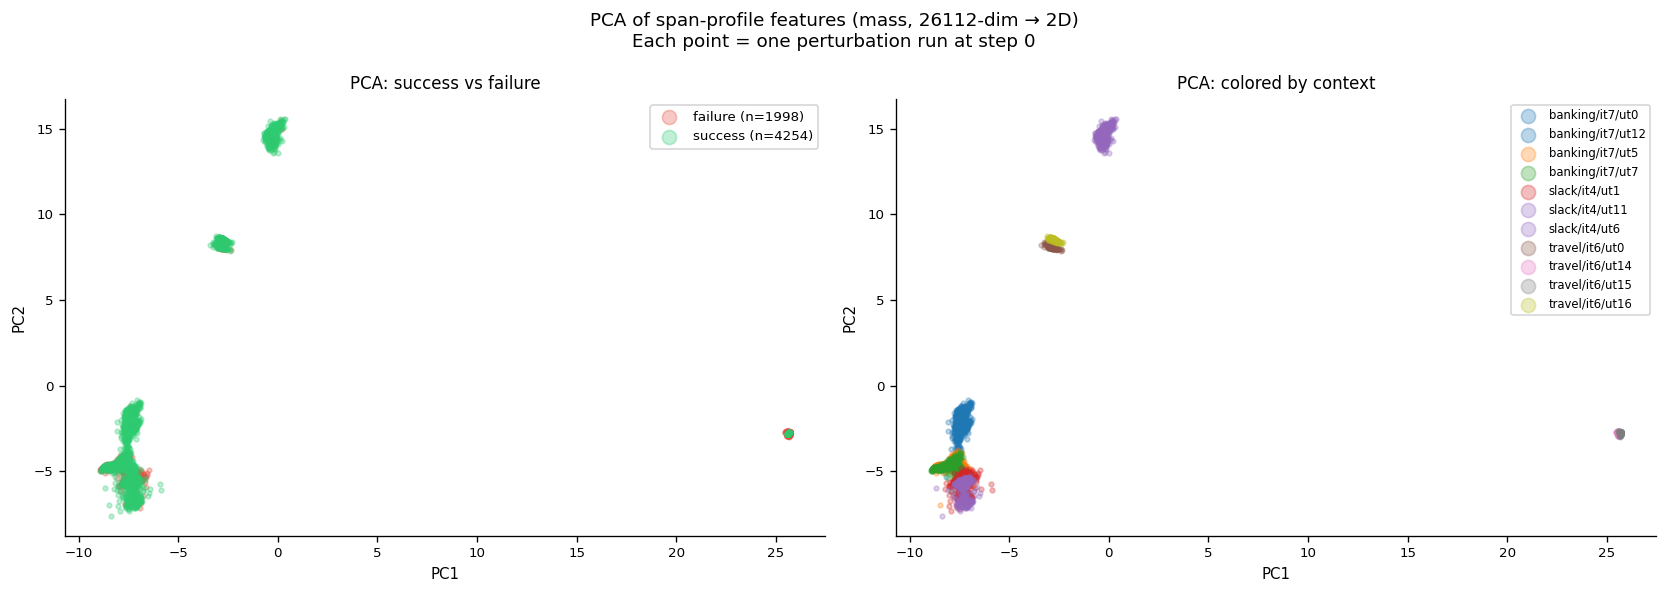

In [ ]:
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_mass)
print(f'PCA variance explained (first 50 PCs): {pca.explained_variance_ratio_.sum():.1%}')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.1%}  PC2: {pca.explained_variance_ratio_[1]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color, name in [(0, '#e74c3c', 'failure'), (1, '#2ecc71', 'success')]:
    mask = y == label
    ax.scatter(X_pca50[mask, 0], X_pca50[mask, 1],
               c=color, alpha=0.3, s=8, label=f'{name} (n={mask.sum()})', rasterized=True)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA: success vs failure')
ax.legend(markerscale=3)

ax = axes[1]
ctx_colors = plt.cm.tab10(np.linspace(0, 0.8, len(context_labels)))
for ci, (cl, col) in enumerate(zip(context_labels, ctx_colors)):
    mask = context_ids == ci
    label = cl.replace('injection_task_', 'it').replace('user_task_', 'ut')
    ax.scatter(X_pca50[mask, 0], X_pca50[mask, 1],
               c=[col], alpha=0.3, s=8, label=label, rasterized=True)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA: colored by context')
ax.legend(markerscale=3, fontsize=7)

plt.suptitle(f'PCA of span-profile features (mass, {N_FEATURES}-dim → 2D)\n'
             'Each point = one perturbation run at step 0', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── 5-fold stratified CV — best model ─────────────────────────────────────────
# Reference estimate: optimistic because all contexts are mixed across folds.
X_best    = feature_variants[BEST_FEAT]
clf_cv    = clone(make_models()[BEST_MODEL])
cv_scores = cross_val_score(
    clf_cv, X_best, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=1,
)
print(f'Best model:      {BEST_FEAT}  +  {BEST_MODEL}')
print(f'5-fold CV AUROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  per fold:      {[f"{s:.3f}" for s in cv_scores]}')
print()
print(f'Cross-context AUROC (ut7 fully held out): {auroc_best:.4f}   ← honest estimate')
print(f'Gap (pooled − cross-context):             {cv_scores.mean() - auroc_best:+.4f}')

In [ ]:
# ── Per-N AUROC — perturbation runs only (confound check) ─────────────────────
# Uses true_cumulative_N (token diff vs baseline, overlap-aware).
# Filters to source='perturbation' for the clean confound check — failure_tree
# runs share seeds and are non-independent at the same true_cumulative_N.
# If AUROC holds at N=1 (single token different from baseline), the signal is
# a genuine attention signature, not a severity proxy.

X_best = feature_variants[BEST_FEAT]

pert_meta = [(i, m) for i, m in enumerate(meta) if m.get('source') == 'perturbation']
tree_meta = [(i, m) for i, m in enumerate(meta) if m.get('source') == 'failure_tree']

all_cum_N  = sorted({m['true_cumulative_N'] for _, m in pert_meta})
tree_cum_N = sorted({m['true_cumulative_N'] for _, m in tree_meta})

print(f'Best model: {BEST_FEAT}  +  {BEST_MODEL}')
print(f'\n── Perturbation-only (clean confound check) ──')
print(f'{"N":>4}  {"n_total":>7}  {"n_succ":>6}  {"n_fail":>6}  {"Pooled CV AUROC":>20}  note')
print('-' * 75)

for n_val in all_cum_N:
    idx   = np.array([i for i, m in pert_meta if m['true_cumulative_N'] == n_val])
    X_n   = X_best[idx]
    y_n   = y[idx]
    n_s, n_f = int(y_n.sum()), int((1 - y_n).sum())
    if n_s < 5 or n_f < 5:
        print(f'{n_val:>4}  {len(idx):>7}  {n_s:>6}  {n_f:>6}  too few of one class')
        continue
    k = min(5, n_f)
    scores = cross_val_score(
        clone(make_models()[BEST_MODEL]), X_n, y_n,
        cv=StratifiedKFold(n_splits=k, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=1,
    )
    note = '<-- single-token flip' if n_val == 1 else ''
    print(f'{n_val:>4}  {len(idx):>7}  {n_s:>6}  {n_f:>6}  '
          f'{scores.mean():>10.4f} ± {scores.std():.4f}  {note}')

if tree_meta:
    print(f'\n── Failure-tree (true_cumulative_N, overlap-corrected) ──')
    print(f'{"N":>4}  {"n_total":>7}  {"n_succ":>6}  {"n_fail":>6}  {"Pooled CV AUROC":>20}')
    print('-' * 60)
    for n_val in tree_cum_N:
        idx  = np.array([i for i, m in tree_meta if m['true_cumulative_N'] == n_val])
        X_n  = X_best[idx]
        y_n  = y[idx]
        n_s, n_f = int(y_n.sum()), int((1 - y_n).sum())
        if n_s < 5 or n_f < 5:
            print(f'{n_val:>4}  {len(idx):>7}  {n_s:>6}  {n_f:>6}  too few of one class')
            continue
        k = min(5, n_f)
        scores = cross_val_score(
            clone(make_models()[BEST_MODEL]), X_n, y_n,
            cv=StratifiedKFold(n_splits=k, shuffle=True, random_state=42),
            scoring='roc_auc', n_jobs=1,
        )
        print(f'{n_val:>4}  {len(idx):>7}  {n_s:>6}  {n_f:>6}  '
              f'{scores.mean():>10.4f} ± {scores.std():.4f}')

In [ ]:
# ── Feature importance — best model ───────────────────────────────────────────
# clf_best was fit on (BEST_FEAT, cross-context train split) in the detail cell.
if hasattr(clf_best, 'coef_'):
    raw_imp   = np.abs(clf_best.coef_[0])
    imp_label = '|coef|'
elif hasattr(clf_best, 'feature_importances_'):
    raw_imp   = clf_best.feature_importances_
    imp_label = 'importance'
else:
    raw_imp = None

if raw_imp is not None and 'step0' in BEST_FEAT and 'ratio' not in BEST_FEAT:
    block_names = ['mass', 'entropy'] if '+entropy' in BEST_FEAT else ['mass']
    is_global   = 'global' in BEST_FEAT
    layers      = GLOBAL_LAYERS if is_global else list(range(N_LAYERS))
    n_layers    = len(layers)

    imp_4d = raw_imp.reshape(len(block_names), n_layers, N_HEADS, N_GROUPS)

    for bi, bname in enumerate(block_names):
        coefs = imp_4d[bi]   # [n_layers, H, G]

        # Group-level bar chart
        grp_imp = coefs.sum(axis=(0, 1))
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(GROUP_NAMES, grp_imp,
               color=[GROUP_COLOR[g] for g in GROUP_NAMES],
               edgecolor='white', alpha=0.9)
        ax.set_xlabel('Span group')
        ax.set_ylabel(f'Total {imp_label}')
        ax.set_title(f'{imp_label} by span group — {bname}\n{BEST_FEAT}  +  {BEST_MODEL}')
        plt.tight_layout(); plt.show()

        # Layer × head heatmap
        fig, ax = plt.subplots(figsize=(14, 4))
        im = ax.imshow(coefs.sum(-1).T, aspect='auto', cmap='viridis',
                       interpolation='nearest', origin='lower')
        ax.set_xlabel('Layer index'); ax.set_ylabel('Head')
        ax.set_title(f'{imp_label} summed over groups — {bname}\n{BEST_FEAT}  +  {BEST_MODEL}')
        ax.set_xticks(range(n_layers))
        ax.set_xticklabels(
            [f'{l}\n{"L" if l in LOCAL_LAYERS else "G"}' for l in layers], fontsize=6
        )
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout(); plt.show()

        # Top 20 triplets
        flat_imp = coefs.reshape(-1)
        top_idx  = np.argsort(flat_imp)[::-1][:20]
        print(f'\nTop 20 ({bname}) by {imp_label}:')
        print(f'{"Rank":>4}  {"Layer":>5}  {"L/G":>3}  {"Head":>4}  {"Group":>16}  {imp_label:>10}')
        print('-' * 55)
        for rank, idx in enumerate(top_idx, 1):
            li = idx // (N_HEADS * N_GROUPS)
            hd = (idx % (N_HEADS * N_GROUPS)) // N_GROUPS
            gi = idx % N_GROUPS
            lg = 'L' if layers[li] in LOCAL_LAYERS else 'G'
            print(f'{rank:>4}  {layers[li]:>5}  {lg:>3}  {hd:>4}  '
                  f'{GROUP_NAMES[gi]:>16}  {flat_imp[idx]:>10.5f}')
else:
    print(f'Structured importance plot not available for feature set: {BEST_FEAT}')
    if raw_imp is not None:
        top = np.argsort(raw_imp)[::-1][:20]
        print(f'Top 20 feature indices: {top.tolist()}')
        print(f'Values: {raw_imp[top].round(5).tolist()}')

In [ ]:
# ── Within-banking leave-one-injection-out (primary analysis) ─────────────────
# For each banking injection as the held-out test set, train on all remaining
# banking injections. Answers: does the attention signature generalise across
# injection tasks within the same environment?
#
# Evaluated on three feature sets × three models to see if non-linear boundaries
# help. Model grid: LogReg (linear), RF (non-linear), GBM (non-linear boosted).

inj_keys   = np.array([m.get('injection_task_id') for m in meta])
suite_keys = np.array([m.get('suite') for m in meta])

banking_injections = sorted({
    m['injection_task_id'] for m in meta if m.get('suite') == 'banking'
})
print('Banking injections with data:', banking_injections)

EVAL_FEATURES = ['step0_global_mass', 'step0_mass', 'step0_global_mass+entropy']

loi_results = []
for held_out in banking_injections:
    train_mask = (suite_keys == 'banking') & (inj_keys != held_out)
    test_mask  = (suite_keys == 'banking') & (inj_keys == held_out)
    y_tr = y[train_mask]
    y_te = y[test_mask]
    n_succ, n_fail = int(y_te.sum()), int((1 - y_te).sum())

    if n_succ < 5 or n_fail < 5:
        print(f'\nHold out {held_out}: skipped — test has succ={n_succ}, fail={n_fail}')
        continue

    print(f'\nHold out {held_out}:')
    print(f'  train n={train_mask.sum()} ({y_tr.sum()} succ / {(1-y_tr).sum()} fail)')
    print(f'  test  n={test_mask.sum()} ({n_succ} succ / {n_fail} fail)')

    row = {'held_out': held_out, 'n_test': int(test_mask.sum()),
           'n_succ': n_succ, 'n_fail': n_fail}

    for feat_name in EVAL_FEATURES:
        X_f = feature_variants[feat_name]
        for model_name, clf_tmpl in make_models().items():
            clf    = clone(clf_tmpl)
            clf.fit(X_f[train_mask], y_tr)
            y_prob = clf.predict_proba(X_f[test_mask])[:, 1]
            auc    = roc_auc_score(y_te, y_prob)
            key    = f'{feat_name}/{model_name}'
            row[key] = round(auc, 4)
            print(f'  {feat_name:38s} + {model_name:10s}: AUROC={auc:.4f}')

    loi_results.append(row)

loi_df = pd.DataFrame(loi_results).set_index('held_out') if loi_results else None

if loi_df is not None:
    print('\n── Leave-one-injection-out AUROC summary ──')
    auroc_cols = [c for c in loi_df.columns if '/' in c]
    print(loi_df[auroc_cols].to_string(float_format='{:.3f}'.format))
    print(f'\nMean AUROC per model × feature:')
    print(loi_df[auroc_cols].mean().sort_values(ascending=False).round(3).to_string())

In [ ]:
# ── Feature importance per held-out injection ──────────────────────────────────
# For each LOI split: refit best model, extract importance, plot layer×head heatmap.
# Shared importance = element-wise min of per-injection normalized importances,
# highlighting heads that matter across ALL injection tasks.

if loi_df is not None and len(loi_results) > 0:
    best_feat_col  = loi_df[[c for c in loi_df.columns if '/' in c]].mean().idxmax()
    best_feat_name, best_model_name = best_feat_col.rsplit('/', 1)

    is_global  = 'global' in best_feat_name
    layers     = GLOBAL_LAYERS if is_global else list(range(N_LAYERS))
    n_layers   = len(layers)

    norm_imps = []

    for row_dict in loi_results:
        held_out   = row_dict['held_out']
        train_mask = (suite_keys == 'banking') & (inj_keys != held_out)
        test_mask  = (suite_keys == 'banking') & (inj_keys == held_out)

        X_f = feature_variants[best_feat_name]
        clf = clone(make_models()[best_model_name])
        clf.fit(X_f[train_mask], y[train_mask])

        if hasattr(clf, 'coef_'):
            raw_imp   = np.abs(clf.coef_[0])
            imp_label = '|coef|'
        elif hasattr(clf, 'feature_importances_'):
            raw_imp   = clf.feature_importances_
            imp_label = 'importance'
        else:
            continue

        # For step0 features: reshape to [n_layers, H, G] (drop entropy block if present)
        has_entropy = '+entropy' in best_feat_name
        n_blocks    = 2 if has_entropy else 1
        imp_4d      = raw_imp.reshape(n_blocks, n_layers, N_HEADS, N_GROUPS)
        coefs       = imp_4d[0]   # mass block: [n_layers, H, G]

        # Layer × head heatmap
        fig, ax = plt.subplots(figsize=(14, 3.5))
        data = coefs.sum(-1).T   # [H, n_layers]
        im   = ax.imshow(data, aspect='auto', cmap='viridis',
                         interpolation='nearest', origin='lower')
        ax.set_xlabel('Layer'); ax.set_ylabel('Head')
        short = held_out.replace('injection_task_', 'it')
        ax.set_title(f'{imp_label} (mass, summed over groups) — hold-out: {short}\n'
                     f'{best_feat_name} + {best_model_name}')
        ax.set_xticks(range(n_layers))
        ax.set_xticklabels(
            [f'{l}\n{"L" if l in LOCAL_LAYERS else "G"}' for l in layers], fontsize=6
        )
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout(); plt.show()

        # Normalize for shared importance
        norm = coefs.sum(-1)
        norm = norm / (norm.max() + 1e-10)
        norm_imps.append(norm)

    # Shared importance: element-wise min across all LOI splits
    if len(norm_imps) > 1:
        shared = np.stack(norm_imps).min(axis=0)   # [n_layers, H]
        fig, ax = plt.subplots(figsize=(14, 3.5))
        im = ax.imshow(shared.T, aspect='auto', cmap='hot',
                       interpolation='nearest', origin='lower')
        ax.set_xlabel('Layer'); ax.set_ylabel('Head')
        ax.set_title(f'Shared importance (min across all LOI splits) — '
                     f'{best_feat_name} + {best_model_name}\n'
                     f'Heads bright here matter regardless of which injection is held out')
        ax.set_xticks(range(n_layers))
        ax.set_xticklabels(
            [f'{l}\n{"L" if l in LOCAL_LAYERS else "G"}' for l in layers], fontsize=6
        )
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout(); plt.show()

        # Top shared triplets
        flat   = shared.reshape(-1)
        top_idx = np.argsort(flat)[::-1][:20]
        print('Top 20 shared (layer, head) by min-normalized importance:')
        print(f'{"Rank":>4}  {"Layer":>5}  {"L/G":>3}  {"Head":>4}  {"shared_imp":>10}')
        print('-' * 42)
        for rank, idx in enumerate(top_idx, 1):
            li = idx // N_HEADS
            hd = idx % N_HEADS
            lg = 'L' if layers[li] in LOCAL_LAYERS else 'G'
            print(f'{rank:>4}  {layers[li]:>5}  {lg:>3}  {hd:>4}  {flat[idx]:>10.4f}')

In [ ]:
# ── Cross-injection ROC curves — one panel per held-out injection ──────────────
if loi_df is not None and len(loi_results) > 0:
    best_feat_col = loi_df[[c for c in loi_df.columns if '/' in c]].mean().idxmax()
    best_feat_name, best_model_name = best_feat_col.rsplit('/', 1)
    print(f'Best combination overall: {best_feat_name}  +  {best_model_name}')

    n_held = len(loi_results)
    fig, axes = plt.subplots(1, n_held, figsize=(5 * n_held, 5), squeeze=False)

    for ax, row_dict in zip(axes[0], loi_results):
        held_out   = row_dict['held_out']
        train_mask = (suite_keys == 'banking') & (inj_keys != held_out)
        test_mask  = (suite_keys == 'banking') & (inj_keys == held_out)
        y_tr = y[train_mask]
        y_te = y[test_mask]

        X_f = feature_variants[best_feat_name]
        clf = clone(make_models()[best_model_name])
        clf.fit(X_f[train_mask], y_tr)
        y_prob = clf.predict_proba(X_f[test_mask])[:, 1]
        auc    = roc_auc_score(y_te, y_prob)

        RocCurveDisplay.from_predictions(y_te, y_prob, ax=ax,
                                          name=f'{best_model_name} (AUC={auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        short = held_out.replace('injection_task_', 'it')
        ax.set_title(f'Hold out: {short}\n(n={row_dict["n_test"]}, '
                     f'succ={row_dict["n_succ"]}, fail={row_dict["n_fail"]})')

    fig.suptitle(f'Leave-one-injection-out ROC — {best_feat_name} + {best_model_name}',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

---
## Generalization hierarchy

| Test | Split | What it measures |
|---|---|---|
| Pooled 5-fold CV | All contexts mixed | Ceiling — optimistic upper bound |
| Per-N pooled | Within each N | Rules out severity-proxy confound |
| Cross-context (it7/ut2 → it7/ut5) | Same payload, different user task | Within-injection context generalization |
| **Leave-one-injection-out** | Train 3 banking injections, test 1 | **Within-suite cross-injection generalization** ← primary |

**If LOI AUROC > ~0.75 consistently**: the signature captures something about the banking environment, not just a specific payload's tokens. Shared importance map highlights the (layer, head) candidates.

**If LOI AUROC is high for some held-out injections but low for others**: the signature is partially injection-specific. Check which injections fail — likely those with structurally different payloads or very unbalanced test sets.

**If LOI AUROC ≈ 0.5 everywhere**: the classifier is learning payload-specific token patterns, not environmental structure. Possible next steps:
- Contrastive normalization: subtract per-injection mean feature vector
- Residual stream features (value aggregates, MLP outputs)
- Focus on global layers only — local layers see at most ~128 tokens and may be too payload-proximate